In [2]:
import numpy as np
import math,copy

In [51]:
def compute_cost(X,y,w,b):
    cost=0.0
    m=X.shape[0]
    for i in range(m):
        f_wb_i=np.dot(X[i],w)+b
        cost=cost+(f_wb_i-y[i])**2
    cost=cost/(2*m)

    return cost
        
    
    

In [52]:
def compute_gradient(X,y,w,b):
    m,n=X.shape
 
    dj_dw=np.zeros((n,))
    dj_db=0.0

    for i in range(m):
        err=(np.dot(X[i],w)+b)-y[i]
        for j in range(n):
            dj_dw[j]=dj_dw[j]+err*X[i,j]
        dj_db=dj_db+err

    dj_dw=dj_dw/m
    dj_db=dj_db/m


    return dj_db,dj_dw
            

In [53]:
def gradient_descent(X,y,w_in,b_in,cost_function,gradient_function,alpha,iterations):

    J_history=[]

    w=copy.deepcopy(w_in)  #to avoid global modifion inside fun
    b=b_in

    for i in range(iterations):
        dj_db,dj_dw=gradient_function(X,y,w,b)

        w=w-alpha*dj_dw
        b=b-alpha*dj_db

        J_history.append(cost_function(X,y,w,b))

        if i%math.ceil(iterations/10)==0:
            print(f"Iteration {i:4d}: cost {J_history[-1]:8.2f}")


    return w,b,J_history
        
    
    

In [56]:
#Data Preparation

X = np.array([
    [2, 1800, 3, 8],
    [5, 1500, 3, 5],
    [12, 1200, 2, 3],
    [20, 1000, 2, 1],
    [8, 2000, 4, 10],
    [15, 1600, 3, 6],
    [25, 900, 2, 2],
    [10, 1400, 3, 7],
    [30, 1100, 2, 4],
    [3, 2200, 4, 12],
    [18, 1700, 3, 8],
    [22, 1300, 2, 5],
    [6, 1900, 4, 9],
    [14, 1550, 3, 4],
    [28, 950, 1, 2],
    [9, 1750, 3, 11],
    [17, 1450, 3, 6],
    [24, 1250, 2, 3],
    [7, 2100, 4, 13],
    [35, 850, 1, 1]
])

y = np.array([
    365, 310, 220, 170, 420,
    300, 145, 285, 180, 470,
    320, 230, 405, 295, 130,
    350, 275, 205, 450, 110
])

X_features=["Age", "Size", "Bedrooms", "Floor"]



In [57]:
def normalize(X):
    mu=np.mean(X,axis=0)
    sigma=np.std(X,axis=0)
    X_norm=(X-mu)/sigma

    return X_norm

In [58]:
w_in=np.zeros(X.shape[1])
b_in=0
alpha=1e-1
iterations=1000
X_scaled=normalize(X)
w,b,J_history=gradient_descent(X_scaled,y,w_in,b_in,compute_cost,compute_gradient,alpha,iterations)

Iteration    0: cost 34427.61
Iteration  100: cost    29.23
Iteration  200: cost    20.46
Iteration  300: cost    16.28
Iteration  400: cost    14.26
Iteration  500: cost    13.28
Iteration  600: cost    12.81
Iteration  700: cost    12.58
Iteration  800: cost    12.47
Iteration  900: cost    12.41


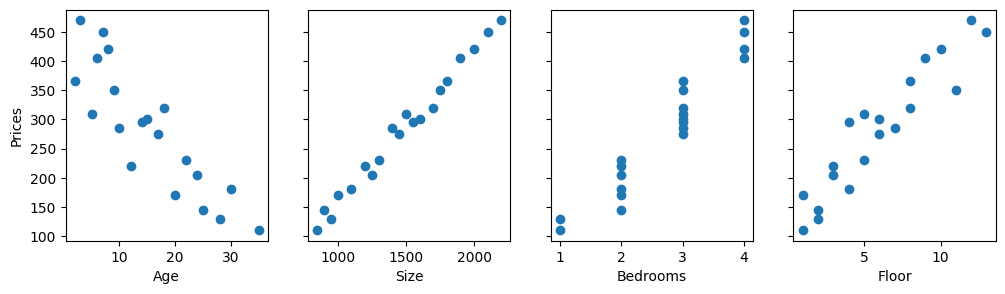

In [59]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,4,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X[:,i],y)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel('Prices')
plt.show()

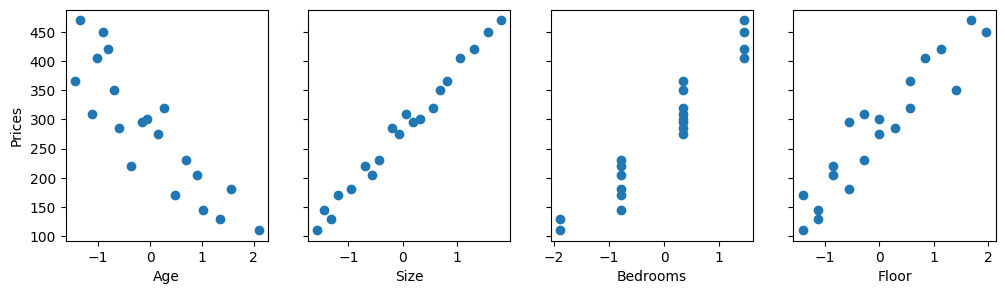

In [60]:
import matplotlib.pyplot as plt
X_scaled=normalize(X)
fig,ax=plt.subplots(1,4,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_scaled[:,i],y)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel('Prices')
plt.show()

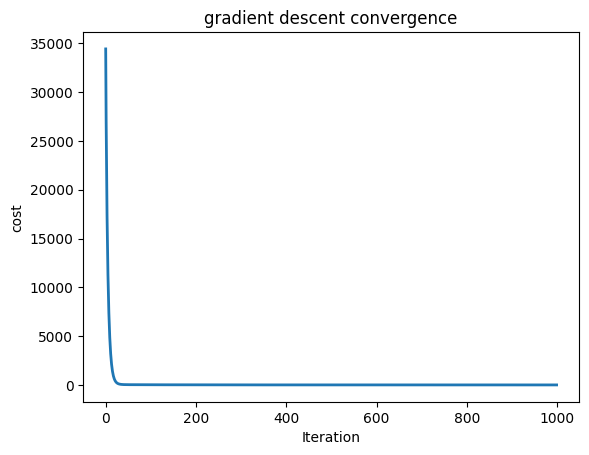

In [61]:
plt.plot(J_history,linewidth=2)
plt.title('gradient descent convergence')
plt.xlabel('Iteration')
plt.ylabel('cost')
plt.show()

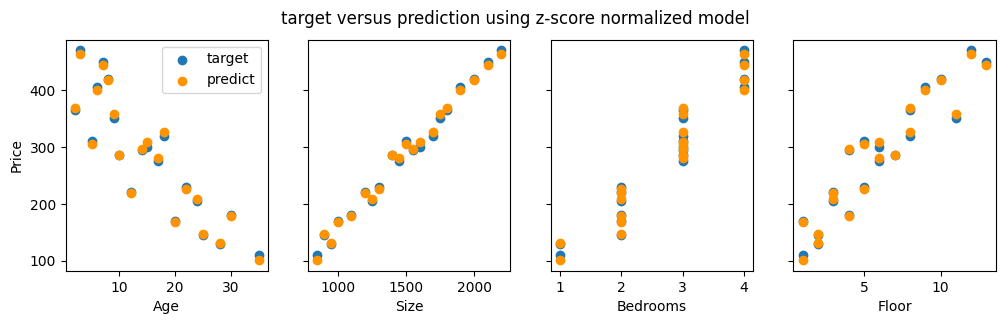

In [74]:
#predict target using normalized features
m = X_scaled.shape[0]
yp = np.zeros(m)
for i in range(m):
    yp[i] = np.dot(X_scaled[i], w) + b

    # plot predictions and targets versus original features    
fig,ax=plt.subplots(1,4,figsize=(12, 3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X[:,i],y, label = 'target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X[:,i],yp,color="#FF9300", label = 'predict')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()

In [62]:
def predict(x,w,b):
    return np.dot(x,w)+b
    

In [73]:
x=[2,1800,3,8]
mu=np.mean(X,axis=0)
sigma=np.std(X,axis=0)
x=(x-mu)/sigma

print(predict(x,w,b))

367.608885302455


In [75]:
from sklearn.metrics import r2_score


r2 = r2_score(y, yp)

print("R² =", r2)

R² = 0.9977362506268918
